### Cargar librerias

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Datos/Transformados/df_unido.csv')
df2 = pd.read_csv('Datos/Transformados/df_AEMET.csv')

C:\Users\Javi\AppData\Local\Temp\ipykernel_16324\3807058211.py:1: DtypeWarning: Columns (56) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Datos/Transformados/df_unido.csv')
C:\Users\Javi\AppData\Local\Temp\ipykernel_16324\3807058211.py:2: DtypeWarning: Columns (48,55,57,61,64,66,69,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('Datos/Transformados/df_AEMET.csv')


In [3]:
df['rate_group_name'].unique()

array(['Non Refundable | B2C', 'Flexible-2d | B2C',
       'Flexible | Travel Trade, Corporate & MICE',
       'Non Refundable | Travel Trade, Corporate & MICE',
       'Flexible | Groups | Best', 'Flexible | Groups | Basic',
       'Flexible | Groups | Super', 'Mid Stay', 'Flexible-7d | B2C',
       'Flexible-30d | B2C'], dtype=object)

In [4]:
print(df.shape)
print(df.columns)
print(df2.shape)
print(df2.columns)


(52004, 82)
Index(['booked_at', 'checkin_time', 'checkout_time', 'lead_time',
       'lenght_of_stay', 'checkin_month', 'checkin_day', 'adult_count',
       'child_count', 'origin', 'travel_agency_name', 'requested_category',
       'requested_category_name', 'asset', 'asset_type', 'brand',
       'asset_opening_date', 'available_units', 'business_segment', 'rate',
       'rate_group_name', 'rate_type', 'completed_entry_forms_count',
       'all_entry_forms_completed', 'last_entry_form_completed_at',
       'returning_inhabitant', 'recurrence', 'libere_community',
       'bought_products', 'product_count', 'reservation_net_value',
       'total_adr', 'status', 'cancelled_at', 'cancellation_reason',
       'cancellation_lead_time', 'ciudad', 'mes_cancelacion',
       'estacion_cancelacion', 'mes_estancia', 'estacion_estancia',
       'mes_reserva', 'estacion_reserva', 'dia_semana_reserva',
       'dia_semana_reserva_nombre', 'dia_semana_cancelacion',
       'dia_semana_cancelacion_nombr

In [5]:
#aplicar funcion mas adelante
df['booked_at'] = pd.to_datetime(df['booked_at'], format="mixed", errors="coerce")
df['checkin_time'] = pd.to_datetime(df['checkin_time'], format="mixed", errors="coerce")
df['checkout_time'] = pd.to_datetime(df['checkout_time'], format="mixed", errors="coerce")
df['asset_opening_date'] = pd.to_datetime(df['asset_opening_date'], format="mixed", errors="coerce")
df['cancelled_at'] = pd.to_datetime(df['cancelled_at'], format="mixed", errors="coerce")
df['last_entry_form_completed_at'] = pd.to_datetime(df['last_entry_form_completed_at'], format="mixed", errors="coerce")
df['completed_entry_forms_count'] = pd.to_numeric(df['completed_entry_forms_count'], errors="coerce")

In [6]:
# nuevas columnas con los mes que es
df['checkin_month'] = df['checkin_time'].dt.month
df['checkout_month'] = df['checkout_time'].dt.month

### Filtramos las variables que consideramos relevantes para el clustering.


In [7]:
# 1) Selección de variables (con canal + geo + estacionalidad + meteo)

# 1. Numéricas (Comportamiento y Valor)
cols_num_cluster = [
    'lead_time',                    # Planificador vs Impulsivo
    'lenght_of_stay',               # Escapada vs Vacaciones
    'adult_count', 'child_count',   # Pareja vs Familia vs Solo
    'available_units',              # Ocupación hotel
    'completed_entry_forms_count',  # Digitalización del cliente
    'product_count',                # Gasto extra
    'reservation_net_value',        # Valor total
    'total_adr',                    # Nivel adquisitivo (Precio noche)
    'espera_dias',                  # Paciencia
    'recurrence',                   # Fidelidad
    'ratio_asistencia',             # Fiabilidad histórica
    # Clima (Contexto)
    'tmed', 'prec', 'sol'           # ¿Viaja con buen o mal tiempo?
]

# 2. Binarias (Perfil y Momento)
cols_bin_cluster = [
    'bought_products',      # ¿Gasta en extras?
    'returning_inhabitant', # ¿Repetidor?
    'libere_community',     # ¿Club fidelidad?
    'es_finde',             # CLAVE: Ocio (True) vs Negocio (False)
    'es_festivo'            # CLAVE: Turismo de puente/fiesta
]

# 3. Categóricas (Contexto Fijo)
cols_cat_cluster = [
    'asset_type',       # ¿Hotel, Hostel, Apartamento?
    'business_segment', # Segmento negocio
    'rate_type',        # ¿Tarifa flexible o no? (Riesgo)
    'origin',           # ¿Viene de Booking o Directo?
    'provincia',        # Destino
    'mes_estancia'      # Estacionalidad
]

cols_cluster = cols_num_cluster + cols_bin_cluster + cols_cat_cluster
df_cluster = df[cols_cluster].copy()

### Limpieza de nulos


In [8]:
# A) Categóricas -> Unknown
df_cluster[cols_cat_cluster] = df_cluster[cols_cat_cluster].fillna('Unknown')

# B) Asegurar numéricas y rellenar nulos con mediana
for c in cols_num_cluster:
    df_cluster[c] = pd.to_numeric(df_cluster[c], errors='coerce')
    df_cluster[c] = df_cluster[c].fillna(df_cluster[c].median())

# C) Transformación de ratio_asistencia (cap p99 + log1p) para evitar ruido/outliers
if 'ratio_asistencia' in df_cluster.columns:
    cap = df_cluster['ratio_asistencia'].quantile(0.99)
    df_cluster['ratio_asistencia'] = df_cluster['ratio_asistencia'].clip(upper=cap)
    df_cluster['ratio_asistencia'] = np.log1p(df_cluster['ratio_asistencia'])

# D) Log1p en variables sesgadas (reduce el dominio de dinero/lead_time y lluvia)
for c in ['reservation_net_value', 'total_adr', 'lead_time', 'prec']:
    if c in df_cluster.columns:
        df_cluster[c] = np.log1p(df_cluster[c])

# E) Binarias -> 0/1 robusto (acepta yes/no, true/false, 1/0)
mapeo = {'yes': 1, 'no': 0}
for col in cols_bin_cluster:
    if df_cluster[col].dtype == 'object':
        df_cluster[col] = df_cluster[col].astype(str).str.lower().map(mapeo).fillna(0).astype(int)
    else:
        df_cluster[col] = df_cluster[col].fillna(0).astype(int)

### Dummies

In [9]:
df_cluster = pd.get_dummies(
    df_cluster,
    columns=cols_cat_cluster,
    drop_first=False
)
df_cluster.to_csv('Datos/Transformados/df_model_dummies_cluster.csv', index=False)

### Correlaciones

No seleccionamos las variables de horatmin, horatmax, horaracha, horaPresMax, horaPresMin (Variables que no nos interesan, que se dummifiquen)

In [ ]:
cols_num = df.select_dtypes(include='number').columns
corr_matrix = df[cols_num].corr()
corr_matrix


,lead_time,lenght_of_stay,checkin_month,adult_count,child_count,available_units,completed_entry_forms_count,recurrence,product_count,reservation_net_value,...,dir,velmedia,racha,sol,presMax,presMin,hrMedia,hrMax,hrMin,checkout_month
lead_time,1.000000,0.098720,0.021591,0.219980,0.008280,0.031931,-0.105437,-0.040999,0.105984,0.176216,...,-0.020642,0.041707,0.027024,-0.016233,-0.009493,-0.008208,0.043200,0.025550,0.060328,0.021114
lenght_of_stay,0.098720,1.000000,-0.020851,-0.030441,-0.045495,-0.064156,-0.094689,0.008916,0.121445,0.449122,...,-0.009177,-0.007898,0.004080,-0.020168,-0.064550,-0.063456,-0.002017,-0.027942,0.000411,-0.020307
checkin_month,0.021591,-0.020851,1.000000,-0.033898,0.029047,0.033344,-0.006194,0.017425,0.035008,0.120021,...,-0.010481,0.005252,0.003766,-0.052585,-0.069953,-0.068965,0.117771,0.046371,0.128078,0.952323
adult_count,0.219980,-0.030441,-0.033898,1.000000,0.005154,-0.200250,0.529033,-0.070794,0.032291,0.330133,...,0.018828,0.044453,0.041456,-0.042397,-0.042040,-0.043785,0.008961,0.006227,-0.018079,-0.042119
child_count,0.008280,-0.045495,0.029047,0.005154,1.000000,-0.014803,0.037940,-0.042310,0.099428,0.128534,...,0.030500,0.022621,0.020963,0.016015,-0.084446,-0.082634,-0.012445,0.001806,-0.027444,0.027182
available_units,0.031931,-0.064156,0.033344,-0.200250,-0.014803,1.000000,-0.183247,0.049063,-0.021643,-0.356842,...,0.056037,0.169626,0.147961,0.024409,-0.044179,-0.042220,0.216006,0.365110,0.179988,0.033379
completed_entry_forms_count,-0.105437,-0.094689,-0.006194,0.529033,0.037940,-0.183247,1.000000,-0.031864,0.087754,0.166317,...,0.024515,0.004818,0.001602,-0.016090,-0.048858,-0.048775,-0.018700,-0.010255,-0.039108,-0.012594
recurrence,-0.040999,0.008916,0.017425,-0.070794,-0.042310,0.049063,-0.031864,1.000000,-0.034578,-0.044424,...,0.003863,0.013265,0.015315,-0.024298,-0.035588,-0.037249,0.034968,0.042197,0.024545,0.018604
product_count,0.105984,0.121445,0.035008,0.032291,0.099428,-0.021643,0.087754,-0.034578,1.000000,0.308032,...,-0.005332,-0.032019,-0.014043,-0.010197,-0.149466,-0.147382,-0.000790,-0.002274,-0.008403,0.028953
reservation_net_value,0.176216,0.449122,0.120021,0.330133,0.128534,-0.356842,0.166317,-0.044424,0.308032,1.000000,...,-0.029650,-0.032503,-0.020917,-0.003519,-0.237659,-0.235163,-0.055187,-0.102507,-0.058156,0.103103


In [ ]:
df_num = df.select_dtypes(include='number')
corr = df_num.corr()
corr

,lead_time,lenght_of_stay,checkin_month,adult_count,child_count,available_units,completed_entry_forms_count,recurrence,product_count,reservation_net_value,...,dir,velmedia,racha,sol,presMax,presMin,hrMedia,hrMax,hrMin,checkout_month
lead_time,1.000000,0.098720,0.021591,0.219980,0.008280,0.031931,-0.105437,-0.040999,0.105984,0.176216,...,-0.020642,0.041707,0.027024,-0.016233,-0.009493,-0.008208,0.043200,0.025550,0.060328,0.021114
lenght_of_stay,0.098720,1.000000,-0.020851,-0.030441,-0.045495,-0.064156,-0.094689,0.008916,0.121445,0.449122,...,-0.009177,-0.007898,0.004080,-0.020168,-0.064550,-0.063456,-0.002017,-0.027942,0.000411,-0.020307
checkin_month,0.021591,-0.020851,1.000000,-0.033898,0.029047,0.033344,-0.006194,0.017425,0.035008,0.120021,...,-0.010481,0.005252,0.003766,-0.052585,-0.069953,-0.068965,0.117771,0.046371,0.128078,0.952323
adult_count,0.219980,-0.030441,-0.033898,1.000000,0.005154,-0.200250,0.529033,-0.070794,0.032291,0.330133,...,0.018828,0.044453,0.041456,-0.042397,-0.042040,-0.043785,0.008961,0.006227,-0.018079,-0.042119
child_count,0.008280,-0.045495,0.029047,0.005154,1.000000,-0.014803,0.037940,-0.042310,0.099428,0.128534,...,0.030500,0.022621,0.020963,0.016015,-0.084446,-0.082634,-0.012445,0.001806,-0.027444,0.027182
available_units,0.031931,-0.064156,0.033344,-0.200250,-0.014803,1.000000,-0.183247,0.049063,-0.021643,-0.356842,...,0.056037,0.169626,0.147961,0.024409,-0.044179,-0.042220,0.216006,0.365110,0.179988,0.033379
completed_entry_forms_count,-0.105437,-0.094689,-0.006194,0.529033,0.037940,-0.183247,1.000000,-0.031864,0.087754,0.166317,...,0.024515,0.004818,0.001602,-0.016090,-0.048858,-0.048775,-0.018700,-0.010255,-0.039108,-0.012594
recurrence,-0.040999,0.008916,0.017425,-0.070794,-0.042310,0.049063,-0.031864,1.000000,-0.034578,-0.044424,...,0.003863,0.013265,0.015315,-0.024298,-0.035588,-0.037249,0.034968,0.042197,0.024545,0.018604
product_count,0.105984,0.121445,0.035008,0.032291,0.099428,-0.021643,0.087754,-0.034578,1.000000,0.308032,...,-0.005332,-0.032019,-0.014043,-0.010197,-0.149466,-0.147382,-0.000790,-0.002274,-0.008403,0.028953
reservation_net_value,0.176216,0.449122,0.120021,0.330133,0.128534,-0.356842,0.166317,-0.044424,0.308032,1.000000,...,-0.029650,-0.032503,-0.020917,-0.003519,-0.237659,-0.235163,-0.055187,-0.102507,-0.058156,0.103103


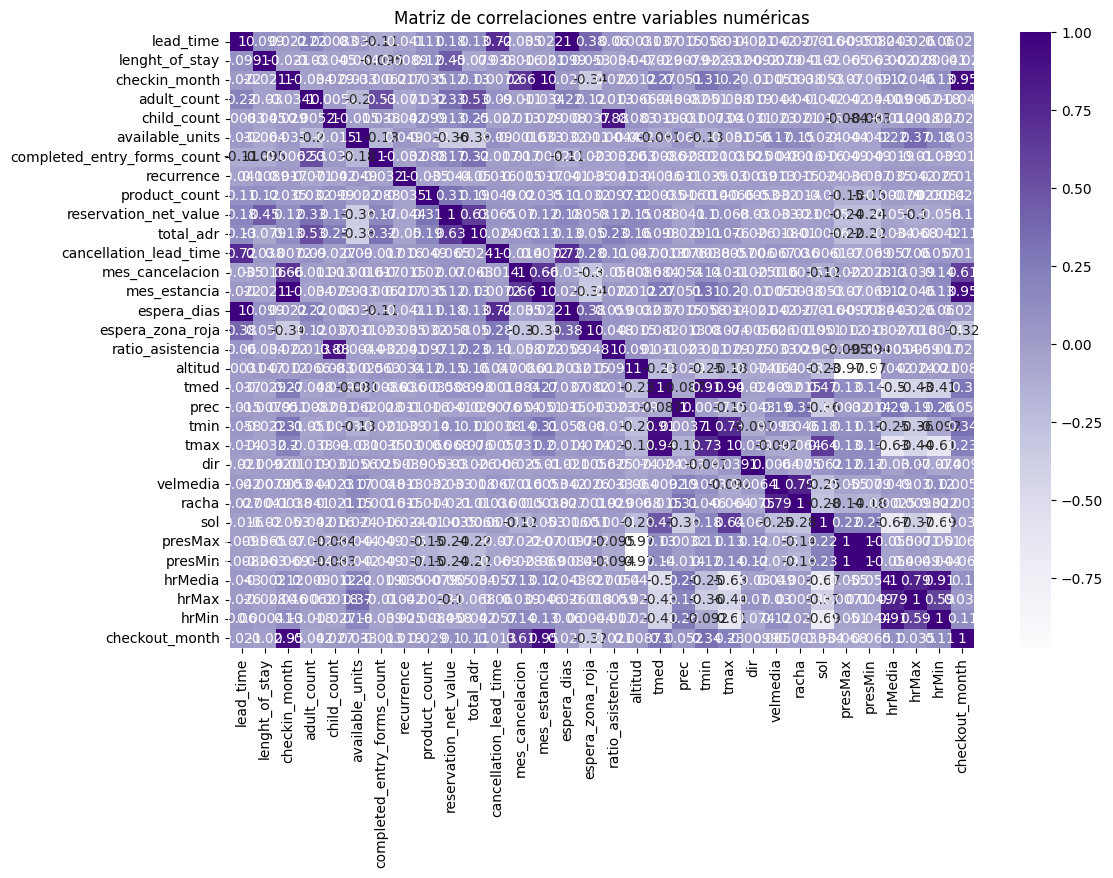

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='Purples', annot=True)
plt.title('Matriz de correlaciones entre variables numéricas')
plt.show()
